# Projet Attrition RH - Partie 2 : Modélisation, Évaluation & Déploiement

**Auteur de cette partie : Chaimae IMRANI**
Projet de groupe (Mohammed MOSLEH & Chaimae IMRANI).

Ce notebook reprend le dataset propre produit par la **Partie 1 (Mohammed)** et fait
tout le travail de **modèle** (J3 + J4) : l'Arène des algos, l'évaluation rigoureuse
(validation croisée, coût métier), puis le déploiement du champion (sérialisation,
API Flask, WebApp Streamlit).

## Phase 1 : Charger le dataset propre et séparer train / validation / test

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

RANDOM_STATE = 42
df = pd.read_csv("data/attrition_clean.csv")
X = df.drop(columns="Attrition").values
y = df["Attrition"].values
features = df.drop(columns="Attrition").columns.tolist()
print("Dataset propre :", df.shape, "| % de departs :", f"{y.mean():.1%}")

Dataset propre : (1470, 48) | % de departs : 16.1%


In [2]:
# Split en 3 jeux, stratifie pour garder l'equilibre du desequilibre partout
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp)
print(f"Train : {len(X_train)} | Validation : {len(X_val)} | Test : {len(X_test)}")

# Scaling : on ajuste le scaler sur le TRAIN seulement (pas de fuite)
scaler = StandardScaler().fit(X_train)
X_train_s, X_val_s, X_test_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

Train : 882 | Validation : 294 | Test : 294


## Phase 2 : L'Arène des algos

Plusieurs algos s'affrontent sur le **même** découpage. Comme la cible est déséquilibrée,
on utilise `class_weight="balanced"` quand c'est possible (le modèle prête plus attention
aux départs, rares mais précieux), et on regarde le **F1** et le **recall**, pas que l'accuracy.

In [3]:
def arene(modeles, X_tr, X_te, y_tr, y_te):
    """Entraine chaque algo et renvoie un classement trie (accuracy, recall, F1)."""
    lignes = []
    for nom, mod in modeles.items():
        mod.fit(X_tr, y_tr)
        pred = mod.predict(X_te)
        lignes.append({"Algo": nom,
                       "Accuracy": round(accuracy_score(y_te, pred), 3),
                       "Recall (partants)": round(recall_score(y_te, pred), 3),
                       "F1": round(f1_score(y_te, pred), 3)})
    return pd.DataFrame(lignes).sort_values("F1", ascending=False)

modeles = {
    "LogisticRegression": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "RandomForest":       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVC_rbf":            SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(n_neighbors=15),
}
# On regle nos choix sur la VALIDATION (le test reste vierge pour la fin)
classement = arene(modeles, X_train_s, X_val_s, y_train, y_val)
print(classement.to_string(index=False))

              Algo  Accuracy  Recall (partants)    F1
           SVC_rbf     0.850              0.553 0.542
  GradientBoosting     0.871              0.383 0.486
LogisticRegression     0.755              0.702 0.478
      RandomForest     0.857              0.170 0.276
               KNN     0.857              0.128 0.222


## Phase 3 : Validation croisée

Un seul découpage est fragile. On valide la stabilité du favori en validation croisée
stratifiée (5 folds), sur le score F1.

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_s = scaler.transform(X)

for nom in ["LogisticRegression", "GradientBoosting", "RandomForest"]:
    scores = cross_val_score(clone(modeles[nom]), X_all_s, y, cv=skf, scoring="f1")
    print(f"{nom:<19}: F1 moyen = {scores.mean():.3f} (+/- {scores.std():.3f})")
print("\nUn ecart-type faible = modele stable, pas un coup de chance du decoupage.")

LogisticRegression : F1 moyen = 0.494 (+/- 0.006)


GradientBoosting   : F1 moyen = 0.412 (+/- 0.049)


RandomForest       : F1 moyen = 0.192 (+/- 0.054)

Un ecart-type faible = modele stable, pas un coup de chance du decoupage.


## Phase 4 : La bonne métrique selon le coût métier

Pour les RH, **rater un employé qui va partir (faux négatif)** coûte cher : on perd un
salarié sans avoir pu réagir (recrutement, formation, perte de compétences). Une fausse
alerte (faux positif) coûte juste un café avec le manager. On compte donc l'argent perdu.

In [5]:
def rapport_metier(y_true, y_pred, cout_fn=10, cout_fp=1, nom=""):
    """Matrice de confusion + precision/recall/F1 + cout metier total."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)
    cout = fn * cout_fn + fp * cout_fp
    print(f"{nom:<19}: precision={p:.2f} recall={r:.2f} F1={f:.2f} | cout metier = {cout}")
    return cout

print("Cout : rater un partant (FN) = 10, fausse alerte (FP) = 1")
print("(sur la VALIDATION)")
for nom in ["LogisticRegression", "GradientBoosting", "RandomForest"]:
    m = clone(modeles[nom]).fit(X_train_s, y_train)
    rapport_metier(y_val, m.predict(X_val_s), nom=nom)

# Baseline naive : "personne ne part"
from numpy import zeros_like
rapport_metier(y_val, zeros_like(y_val), nom="Baseline (aucun depart)")
print("-> La baseline a une bonne accuracy mais rate TOUS les partants : cout metier enorme.")

Cout : rater un partant (FN) = 10, fausse alerte (FP) = 1
(sur la VALIDATION)
LogisticRegression : precision=0.36 recall=0.70 F1=0.48 | cout metier = 198


GradientBoosting   : precision=0.67 recall=0.38 F1=0.49 | cout metier = 299


RandomForest       : precision=0.73 recall=0.17 F1=0.28 | cout metier = 393
Baseline (aucun depart): precision=0.00 recall=0.00 F1=0.00 | cout metier = 470
-> La baseline a une bonne accuracy mais rate TOUS les partants : cout metier enorme.


## Phase 5 : Le champion, sur le jeu de test (verdict final)

On choisit la **régression logistique** : bon recall sur les partants (l'essentiel ici),
rapide, et surtout **explicable** (on peut dire au RH quels facteurs pèsent). On la juge
une seule fois sur le test, vierge jusqu'ici.

In [6]:
champion = LogisticRegression(max_iter=5000, class_weight="balanced").fit(X_train_s, y_train)
y_pred = champion.predict(X_test_s)
proba = champion.predict_proba(X_test_s)[:, 1]

print("=== VERDICT FINAL (jeu de test) ===")
print(classification_report(y_test, y_pred, target_names=["reste", "part"]))
print("AUC :", round(roc_auc_score(y_test, proba), 3))

=== VERDICT FINAL (jeu de test) ===
              precision    recall  f1-score   support

       reste       0.92      0.78      0.85       247
        part       0.36      0.66      0.47        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.66       294
weighted avg       0.83      0.76      0.79       294

AUC : 0.782


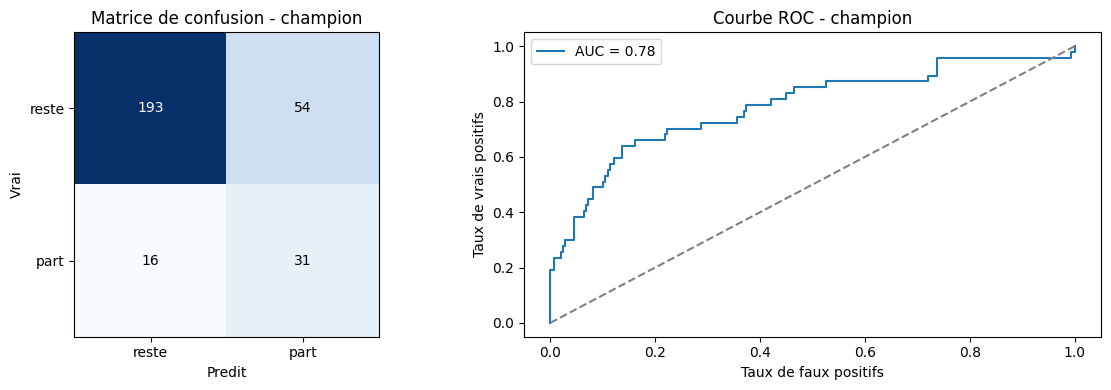

In [7]:
# Matrice de confusion + courbe ROC du champion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
im = ax1.imshow(cm, cmap="Blues")
ax1.set_title("Matrice de confusion - champion")
ax1.set_xticks([0, 1]); ax1.set_xticklabels(["reste", "part"])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["reste", "part"])
ax1.set_xlabel("Predit"); ax1.set_ylabel("Vrai")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")

fpr, tpr, _ = roc_curve(y_test, proba)
ax2.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, proba):.2f}")
ax2.plot([0, 1], [0, 1], "--", color="grey")
ax2.set_xlabel("Taux de faux positifs"); ax2.set_ylabel("Taux de vrais positifs")
ax2.set_title("Courbe ROC - champion"); ax2.legend()
plt.tight_layout(); plt.show()

## Phase 6 : Déployer le champion

On sérialise le modèle + le scaler + les noms de features ensemble (sinon les prédictions
en prod seraient fausses). Les fichiers `api.py` (Flask) et `app.py` (Streamlit) rechargent
ce `modele.joblib`.

In [8]:
# On re-entraine le champion sur train+val pour le deploiement (plus de donnees)
X_deploy = np.vstack([X_train, X_val])
y_deploy = np.concatenate([y_train, y_val])
scaler_final = StandardScaler().fit(X_deploy)
champion_final = LogisticRegression(max_iter=5000, class_weight="balanced").fit(
    scaler_final.transform(X_deploy), y_deploy)

plages = {"min": X_deploy.min(axis=0), "max": X_deploy.max(axis=0)}
joblib.dump({"modele": champion_final, "scaler": scaler_final,
             "features": features, "plages": plages}, "modele.joblib")
print("Champion serialise dans modele.joblib (", len(features), "features )")

Champion serialise dans modele.joblib ( 47 features )


In [9]:
def predire(features_values, chemin="modele.joblib"):
    """Logique de l'endpoint /predict : valide, normalise, predit."""
    b = joblib.load(chemin)
    if not isinstance(features_values, (list, np.ndarray)) or len(features_values) != len(b["features"]):
        return {"error": f"il faut {len(b['features'])} features numeriques"}, 400
    try:
        x = np.array(features_values, dtype=float).reshape(1, -1)
    except (ValueError, TypeError):
        return {"error": "les features doivent etre des nombres"}, 400
    x_s = b["scaler"].transform(x)
    pred = int(b["modele"].predict(x_s)[0])
    proba = float(b["modele"].predict_proba(x_s)[0][1])
    res = {"prediction": pred, "proba_depart": round(proba, 3),
           "label": "risque de depart" if pred == 1 else "va probablement rester"}
    return res, 200

# Trois cas de test
print("Cas normal     :", predire(X_test[0].tolist())[0])
print("Cas limite     :", predire([1, 2, 3]))            # mauvais nombre de valeurs -> 400
print("Cas adversarial:", predire(["texte"] * len(features)))  # du texte -> 400

Cas normal     : {'prediction': 0, 'proba_depart': 0.244, 'label': 'va probablement rester'}
Cas limite     : ({'error': 'il faut 47 features numeriques'}, 400)
Cas adversarial: ({'error': 'les features doivent etre des nombres'}, 400)


---
### Bilan Partie 2 (et du projet)

- **Arène** : 5 algos comparés sur le même découpage. Sur du déséquilibré, on juge au
  **F1 / recall**, pas à l'accuracy.
- **Évaluation** : validation croisée stratifiée (stabilité) + **coût métier** (rater un
  partant coûte 10x une fausse alerte).
- **Champion : la régression logistique** — bon recall sur les partants, rapide, et
  **explicable** (on peut justifier au RH pourquoi un employé est à risque : heures
  supplémentaires, salaire, ancienneté...).
- **Déploiement** : modèle sérialisé (`modele.joblib`) + API Flask (`api.py`) + WebApp
  Streamlit (`app.py`).

**Conclusion métier** : le service RH peut faire tourner les profils dans la WebApp et
recevoir, pour chaque employé, une probabilité de départ → cibler les actions de rétention
sur les bons profils plutôt que d'agir à l'aveugle.